In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc

In [13]:
def function(num):  # проверочная функция -- тангенс
    x = np.linspace(-1.5, 1.5, num)
    f = np.tan(x)
    return f, x

In [14]:
def nodes(a, b, n):  # узлы Чебышёва
    pi = sc.constants.pi
    x = [0.5*(a+b) + 0.5*(b-a) * np.cos(pi*((2*m - 1)/(2*n))) for m in range(1, n+1)]
    return x

In [32]:
def spline3plot():
    x = nodes(1.5, -1.5, 10)
    y = np.tan(X)
    y_teor, x_teor = function(1000)
    cubicspline = sc.interpolate.CubicSpline(x, y) # типа построение сплайна для точек x y
    xs = np.linspace(-1.5, 1.5, 1000) # x координаты сплайна
    ys = cubicspline(xs)  # y координаты сплайна
    
    fig1 = plt.figure(figsize=(15, 6))
    ax1 = fig1.add_subplot(121)
    plt.scatter(x, y, color='crimson')  # точки, по которым строится сплайн
    plt.plot(x_teor, y_teor, color='darkcyan')  # теор. значения функции
    plt.plot(xs, ys, color='red') # сплайн
    ax2 = fig1.add_subplot(122)
    plt.plot(x_teor, y_teor-ys, color='black') 
    plt.show

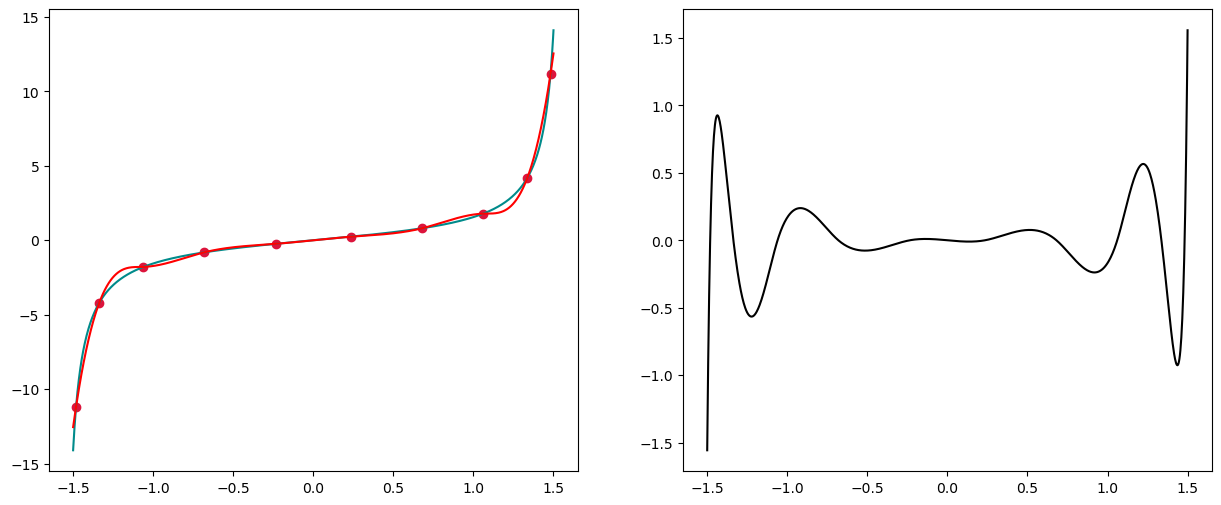

In [33]:
spline3plot()

In [195]:
def spline3_coeffs(x, y):  # эта функция не работает, я запуталась
    n = len(x) - 1 # индекс от 0
    h = []
    for i in range(1, n):
        h.append(x[i] - x[i-1])
    main_diag = []
    diags = []
    for i in range(1, n):
        main_diag.append(2*(h[i]+h[i+1]))
    for i in range(2, n):
        diags.append(h[i])
    b = [6*((y[2]-y[1]/h[1])+(y[1]-y[0]/h[0]))]
    for i in range(1, len(y)-2):
        b.append(6*((y[i+2]-y[i+1]/h[i+1])+(y[i+1]-y[i]/h[i])))
    strs = []
    strs.append([main_diag[0], diags[0]])
    strs[0].extend(np.linspace(0, 0, len(b)-2))
    for i in range(1, len(b)-1):
        left_z = np.linspace(0, 0, i-1)
        strs.append(list(left_z))
        strs[i].extend([diags[i], main_diag[i], diags[i]])
        right_z = np.linspace(0, 0, len(b) - i - 2)
        strs[i].extend(right_z)
    strs.append(list(np.linspace(0, 0, len(b)-2)))
    strs[-1].extend([diags[-1], main_diag[-1]])
    strs = np.array(strs)
    b = np.array([[b[i]] for i in range(len(b))])
    #spline_koefs
    c = [0]
    cc = [a[0] for a in np.linalg.solve(strs, b)]
    c.extend(cc)
    c.append(0)
    d = [(c[i] - c[i-1])/h[i-1] for i in range(1, len(c))] #без d0
    b = [(((h[i-1])*c[i])/2 - (h[i-1]**2/6)*d[i-1] + (y[i]-y[i-1])/h[i-1]) for i in range(1, len(c))] #безb0
    a = y[1:]
    c = c[1:]
    return a, b, c, d
def cube(x, a, b, c, d):  
    return (d/6)*x**3+0.5*c*x**2+b*x+d   